In [1]:
from os import environ
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset_url = (
    "https://datasets.cellxgene.cziscience.com/"
    "3b751975-34bb-409a-a9b7-98380f0450ea.h5ad"
)
dataset_directory = Path(environ.get("SCARF_DOCS_DATA_DIR", "scarf_datasets"))
dataset_directory.mkdir(parents=True, exist_ok=True)
h5ad_path = dataset_directory / "binvignat_ra_pbmc.h5ad"

if not h5ad_path.exists():
    partial_path = h5ad_path.with_suffix(".h5ad.part")
    urlretrieve(dataset_url, partial_path)
    partial_path.replace(h5ad_path)

inspection = scarf.inspect_h5ad(str(h5ad_path))
assert inspection.matrixKey == "raw/X"
assert inspection.integerLike is True
assert (inspection.nCells, inspection.nFeatures) == (108_717, 21_648)
{
    "matrix": inspection.matrixKey,
    "encoding": inspection.matrixEncoding,
    "integer-like": inspection.integerLike,
    "shape": (inspection.nCells, inspection.nFeatures),
}

{'matrix': 'raw/X',
 'encoding': 'csr',
 'integer-like': True,
 'shape': (108717, 21648)}

In [2]:
source_store = dataset_directory / "binvignat_ra_pbmc.zarr"
if not source_store.exists():
    with TemporaryDirectory(dir=dataset_directory) as conversion_directory:
        staged_store = Path(conversion_directory) / source_store.name
        reader = scarf.H5adReader.from_inspect(inspection)
        try:
            scarf.H5adToZarr(
                reader,
                zarr_loc=str(staged_store),
                nthreads=4,
            ).dump()
        finally:
            reader.h5.close()
        staged_store.replace(source_store)

source = scarf.DataStore(
    str(source_store),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)
assert int(np.asarray(source.cells.fetch_all("I"), dtype=bool).sum()) == 108_717

analysis_directory = TemporaryDirectory()
ds = scarf.mount_datastore(
    str(source_store),
    at=str(Path(analysis_directory.name) / "ra_pseudobulk.zarr"),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)

In [3]:
cell_metadata = pd.DataFrame(
    {
        column: ds.cells.fetch_all(column)
        for column in (
            "donor_id",
            "disease",
            "batch",
            "pair_index_CW",
            "fine_annot",
        )
    }
)
cell_metadata["pair_index_CW"] = pd.to_numeric(
    cell_metadata["pair_index_CW"],
    errors="coerce",
)

selection_mask = pd.Series(
    np.isfinite(cell_metadata["pair_index_CW"].to_numpy(dtype=float)),
    index=cell_metadata.index,
) & cell_metadata["fine_annot"].eq("yd T cells")
ds.cells.insert(
    "paired_yd_t_cells",
    selection_mask.to_numpy(),
    overwrite=True,
)
selection = ds.snapshot_cell_selection("paired_yd_t_cells")

pd.Series(
    {
        "selected cells": int(selection_mask.sum()),
        "represented donors": int(
            cell_metadata.loc[selection_mask, "donor_id"].nunique()
        ),
    }
)

selected cells        1386
represented donors      36
dtype: int64

In [4]:
bulk = ds.make_bulk(
    "donor_id",
    cell_selection=selection,
    aggr_type="sum",
    feature_label="name",
)
assert bulk.shape == (13_547, 36)
bulk.iloc[:5, :6]

,Control01_1_A_M,Control03_1_C_F,Control04_1_C_F,Control05_1_C_M,Control06_1_C_M,Control07_1_C_F
LINC01409,0,0,1,0,0,0
LINC00115,0,0,1,0,0,0
SAMD11,1,0,0,0,0,0
NOC2L,0,1,0,0,0,0
KLHL17,0,0,0,0,0,0


In [5]:
selected_metadata = cell_metadata.loc[
    selection_mask,
    ["donor_id", "disease", "batch", "pair_index_CW"],
].copy()

within_donor_levels = selected_metadata.groupby("donor_id", sort=False)[
    ["disease", "pair_index_CW", "batch"]
].nunique(dropna=False)
assert within_donor_levels.eq(1).all().all()

donor_metadata = (
    selected_metadata[["donor_id", "disease", "pair_index_CW", "batch"]]
    .drop_duplicates()
    .set_index("donor_id")
)
donor_metadata = donor_metadata.reindex(bulk.columns)
assert donor_metadata.index.is_unique
assert donor_metadata.notna().all().all()

disease_counts = donor_metadata["disease"].value_counts()
assert disease_counts.to_dict() == {
    "normal": 18,
    "rheumatoid arthritis": 18,
}

pair_sizes = donor_metadata.groupby("pair_index_CW").size()
pair_conditions = donor_metadata.groupby("pair_index_CW")["disease"].nunique()
assert len(pair_sizes) == 18
assert pair_sizes.eq(2).all()
assert pair_conditions.eq(2).all()

donor_metadata.groupby(["batch", "disease"]).size().unstack(fill_value=0)

disease,normal,rheumatoid arthritis
batch,,
1,7,7
2,4,3
3,7,8


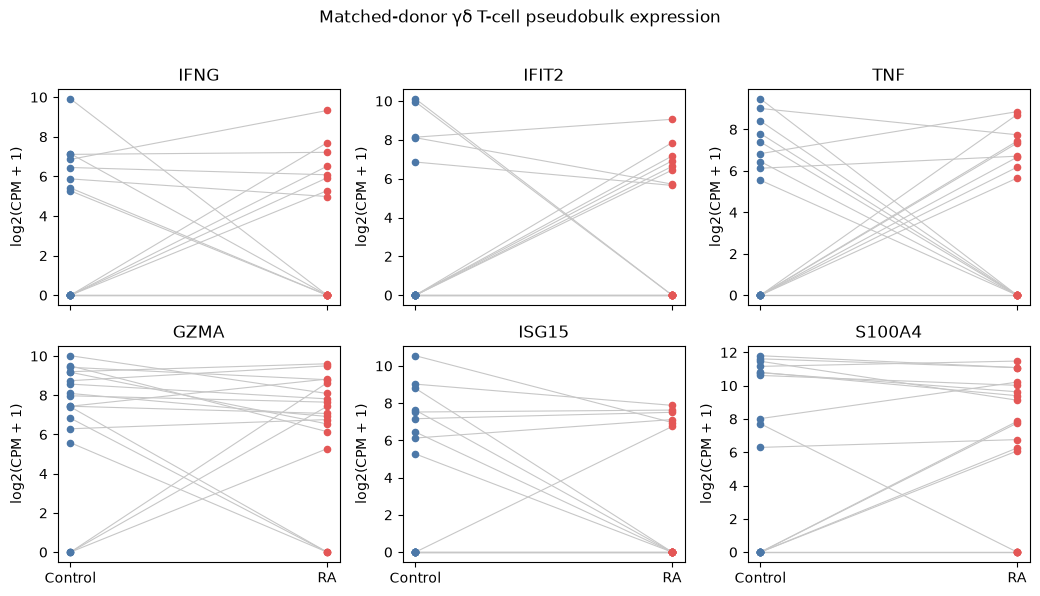

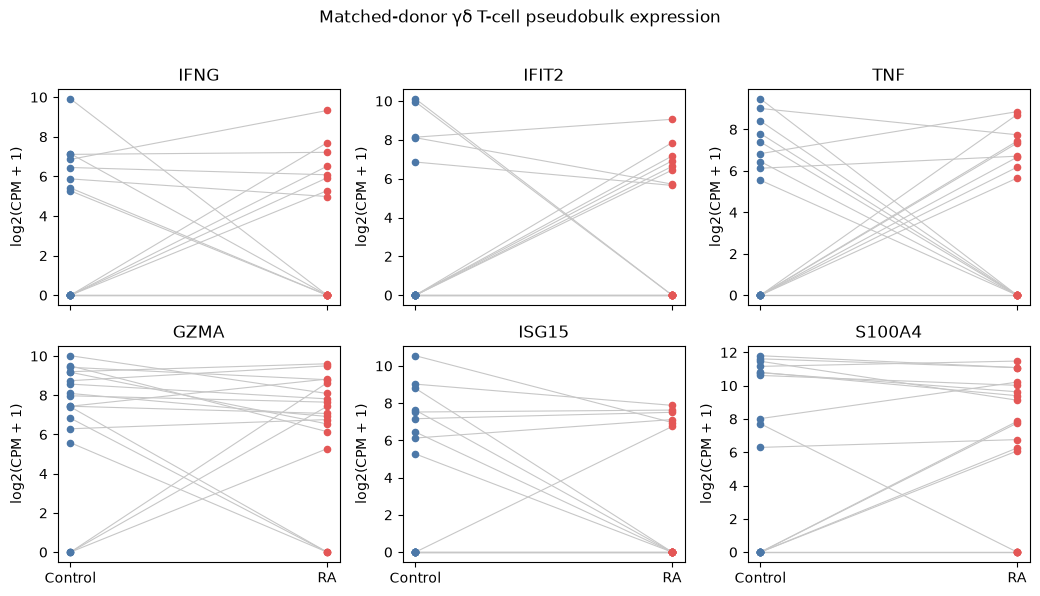

In [6]:
panel_genes = ["IFNG", "IFIT2", "TNF", "GZMA", "ISG15", "S100A4"]
missing_genes = sorted(set(panel_genes).difference(bulk.index))
assert not missing_genes, f"Missing panel genes: {missing_genes}"

library_sizes = bulk.sum(axis=0)
assert library_sizes.gt(0).all()
log2_cpm = np.log2(bulk.div(library_sizes, axis=1).mul(1_000_000) + 1)
panel = log2_cpm.loc[panel_genes].T.join(donor_metadata)

condition_order = ("normal", "rheumatoid arthritis")
condition_colors = {
    "normal": "#4C78A8",
    "rheumatoid arthritis": "#E45756",
}
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.8), sharex=True)
for gene, ax in zip(panel_genes, axes.flat, strict=True):
    for _, paired in panel.groupby("pair_index_CW", sort=True):
        ordered = paired.set_index("disease").reindex(condition_order)
        ax.plot(
            (0, 1),
            ordered[gene],
            color="0.78",
            linewidth=0.8,
            zorder=1,
        )
    for position, condition in enumerate(condition_order):
        values = panel.loc[panel["disease"].eq(condition), gene]
        ax.scatter(
            np.full(len(values), position),
            values,
            color=condition_colors[condition],
            s=20,
            zorder=2,
        )
    ax.set_title(gene)
    ax.set_xticks((0, 1), ("Control", "RA"))
    ax.set_ylabel("log2(CPM + 1)")

fig.suptitle("Matched-donor γδ T-cell pseudobulk expression", y=1.02)
fig.tight_layout()
fig

In [7]:
export_directory = TemporaryDirectory()
counts_csv = Path(export_directory.name) / "yd_t_cell_raw_counts.csv"
metadata_csv = Path(export_directory.name) / "yd_t_cell_donor_design.csv"

bulk.to_csv(counts_csv)
donor_metadata.index.name = "donor_id"
donor_metadata.to_csv(metadata_csv)

pd.read_csv(metadata_csv, index_col="donor_id").head()

,disease,pair_index_CW,batch
donor_id,,,
Control01_1_A_M,normal,1.0,1
Control03_1_C_F,normal,3.0,1
Control04_1_C_F,normal,4.0,1
Control05_1_C_M,normal,5.0,1
Control06_1_C_M,normal,6.0,1
